In [ ]:
import torch


def measure_homophily_heterophily(data, ignore_self_loops=True, undirected=True):
    """
    Mede homofilia e heterofilia de um grafo no formato PyTorch Geometric.

    Parâmetros
    ----------
    data : torch_geometric.data.Data
        Objeto Data do PyG contendo pelo menos:
        - data.edge_index: tensor [2, num_edges]
        - data.y: tensor [num_nodes]

    ignore_self_loops : bool
        Se True, ignora arestas do tipo (i, i).

    undirected : bool
        Se True, evita contar duas vezes arestas duplicadas em grafos não direcionados,
        por exemplo (i, j) e (j, i).

    Retorna
    -------
    dict
        Dicionário com homofilia, heterofilia e contagens de arestas.
    """

    edge_index = data.edge_index
    y = data.y

    src = edge_index[0]
    dst = edge_index[1]

    # Remove self-loops, se desejado
    if ignore_self_loops:
        mask = src != dst
        src = src[mask]
        dst = dst[mask]

    # Evita contar duas vezes arestas simétricas em grafos não direcionados
    if undirected:
        mask = src < dst
        src = src[mask]
        dst = dst[mask]

    # Garante que estamos comparando vetores 1D
    y = y.view(-1)

    # Compara os rótulos dos nós conectados
    same_class = y[src] == y[dst]

    num_edges = same_class.numel()
    num_same = same_class.sum().item()
    num_diff = num_edges - num_same

    if num_edges == 0:
        return {
            "homophily": None,
            "heterophily": None,
            "num_edges": 0,
            "num_same_class_edges": 0,
            "num_different_class_edges": 0,
        }

    homophily = num_same / num_edges
    heterophily = num_diff / num_edges

    return {
        "homophily": homophily,
        "heterophily": heterophily,
        "num_edges": num_edges,
        "num_same_class_edges": num_same,
        "num_different_class_edges": num_diff,
    }

# Gerador de grafos heterofilicos

In [ ]:
import torch
from models.SCatt import SCAttGenerator

target_heterophily = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

y = [200, 200, 200, 200, 200, 200]
target_num_edges = 3000
d = ["power_law", "power_law", "normal", "normal", "uniform", "uniform"]
k = 6

M = [
    torch.tensor([1]),
    torch.tensor([1/3, 1/3, 1/3])
] * 3

C = [
    torch.tensor([1]),
    torch.tensor([[1/3,1/3,1/3],[1/3,1/3,1/3],[1/3,1/3,1/3]])
] * 3

N = (torch.ones(size = (6,6)) * 1/5) - (torch.eye(6) * 1/5)

for tgt_het in target_heterophily:

    graph = SCAttGenerator(seed=42).generate(
        num_nodes=sum(y),
        y=y,
        k=k,
        e=[1, 1, 1,1,1,1],
        C=C,
        d=d,
        N=N,
        M=M,
        target_num_edges=target_num_edges,
        target_heterophily=tgt_het,
        dimensions=512,
        sigma=0.2,
        alpha=0.6,
    )


    torch.save(graph.to_data_pytorch(), f"scatt_graph_hetero_{tgt_het}.pt")

    print(f"save at scatt_graph_hetero_{tgt_het}.pt")

# Aumentando a quantidade de vértices

In [ ]:
import torch
from models.SCatt import SCAttGenerator

target_heterophily = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


multiplier = [1,2,3,4,5,6,7,8,9,10]
tmp_y = [100,100,100,100,100,100]
tmp_target_num_edges = 1500
d = ["power_law", "power_law", "normal", "normal", "uniform", "uniform"]
k = 6

M = [
    torch.tensor([1]),
    torch.tensor([1/3, 1/3, 1/3])
] * 3

C = [
    torch.tensor([1]),
    torch.tensor([[1/3,1/3,1/3],[1/3,1/3,1/3],[1/3,1/3,1/3]])
] * 3

N = (torch.ones(size = (6,6)) * 1/5) - (torch.eye(6) * 1/5)

for mt in multiplier:
    y = [x * mt for x in tmp_y]
    target_num_edges = tmp_target_num_edges*mt

    graph = SCAttGenerator(seed=42).generate(
        num_nodes=sum(y),
        y=y,
        k=k,
        e=[1, 1, 1,1,1,1],
        C=C,
        d=d,
        N=N,
        M=M,
        target_num_edges=target_num_edges,
        target_heterophily=0.2,
        dimensions=512,
        sigma=0.2,
        alpha=0.6,
    )


    torch.save(graph.to_data_pytorch(), f"scatt_graph_{sum(y)}_edges.pt")

    print(graph.to_data_pytorch)

    print(f"scatt_graph_{sum(y)}_edges.pt")

# Plots do Artigo

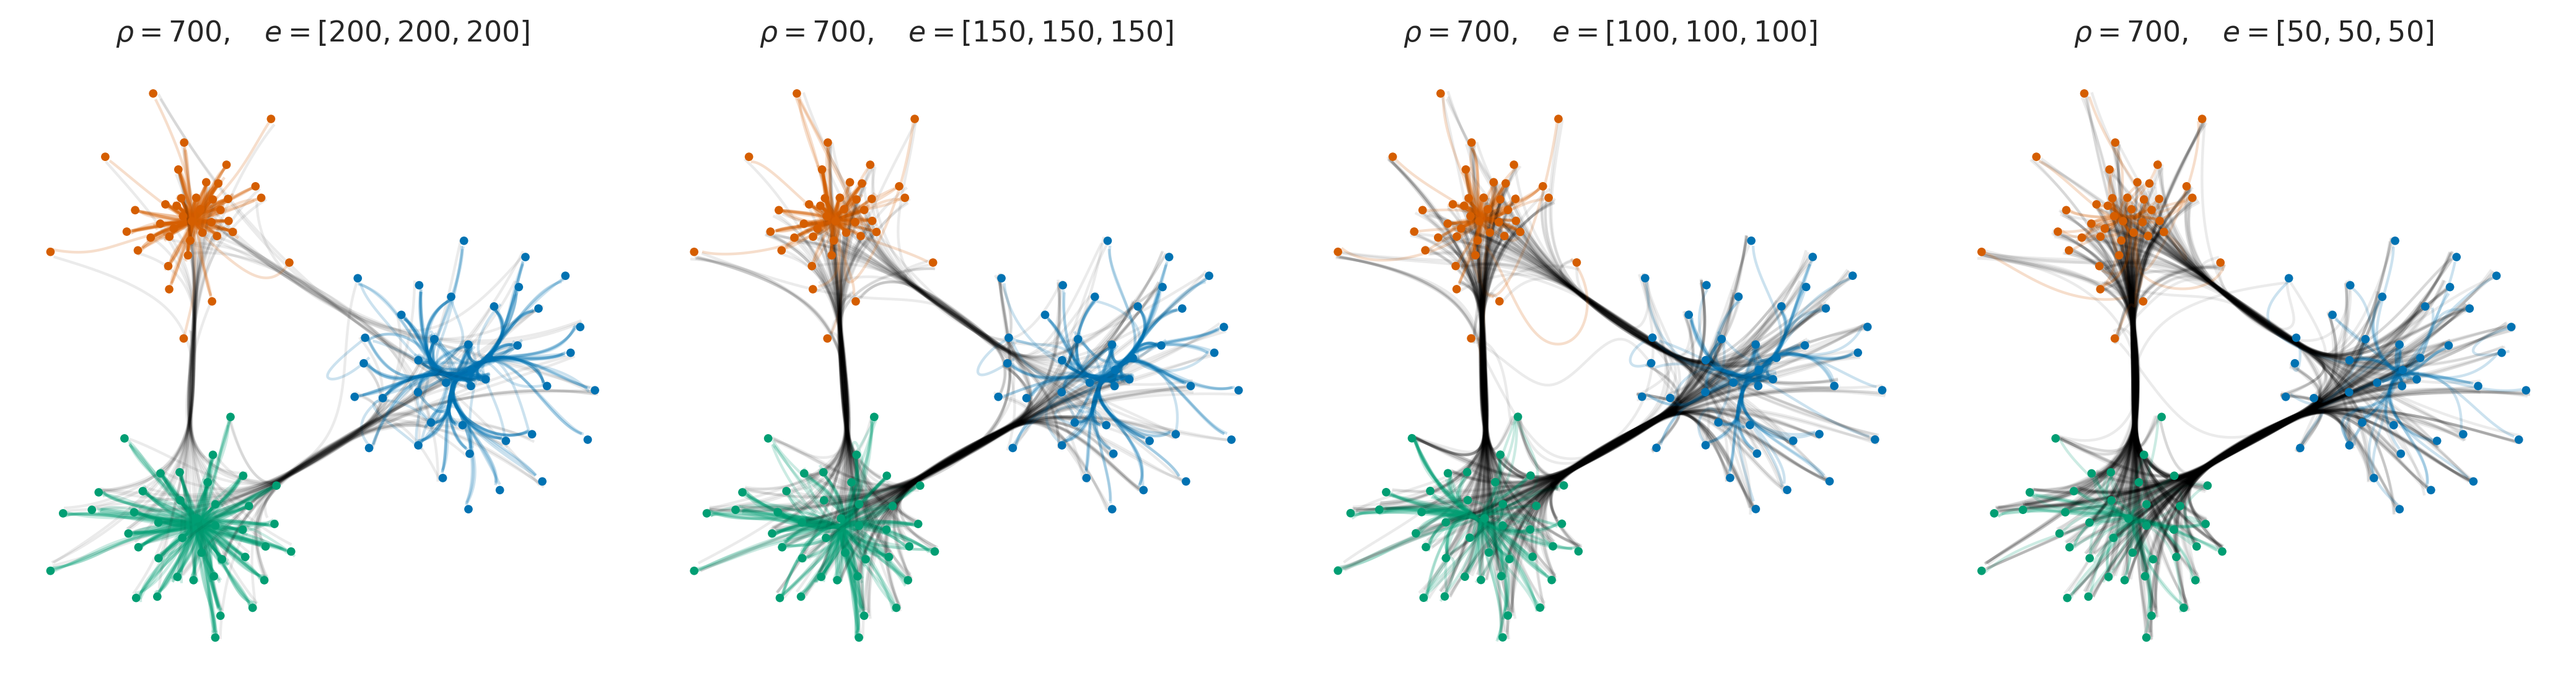

In [2]:
import torch
import matplotlib.pyplot as plt

from models.SCatt import SCAttGenerator
from plot.plot import PublicationPlotStyle, graphPlotter


# -------------------------
# Parametros base do SCAtt
# -------------------------

y = [40, 40, 40]
k = len(y)
n = sum(y)

S = [
    torch.tensor([1.0]),
    torch.tensor([0.4, 0.3, 0.3]),
    torch.tensor([0.9, 0.1]),
]

A_in = [
    torch.tensor([[1.0]]),
    torch.tensor([
        [0.6, 0.3, 0.1],
        [0.1, 0.7, 0.2],
        [0.0, 0.3, 0.7],
    ]),
    torch.tensor([
        [0.9, 0.1],
        [0.1, 0.9],
    ]),
]

A_out = torch.tensor([
    [0.0, 0.2, 0.8],
    [0.3, 0.0, 0.7],
    [0.5, 0.5, 0.0],
])

dst = ["power_law", "normal", "uniform"]


# ----------------------------------------
# Cenarios: intra diminui, inter aumenta
# rho = total de arestas
# inter = rho - sum(e)
# ----------------------------------------

scenarios = [
    {"e": [200, 200, 200], "rho": 700, "title": r"$\rho = 700, \quad e = [200, 200, 200]$"},
    {"e": [150, 150, 150], "rho": 700, "title": r"$\rho = 700, \quad e = [150, 150, 150]$"},
    {"e": [100, 100, 100], "rho": 700, "title": r"$\rho = 700, \quad e = [100, 100, 100]$"},
    {"e": [50, 50, 50],   "rho": 700, "title":  r"$\rho = 700, \quad e = [50, 50, 50]$"},
]


# -------------------------
# Geracao dos grafos
# -------------------------

graphs = []

for scenario in scenarios:
    graph = SCAttGenerator(seed=42).generate(
        n=n,
        k=k,
        y=y,
        e=scenario["e"],
        dst=dst,
        S=S,
        A_in=A_in,
        A_out=A_out,
        rho=scenario["rho"],
        d=60,
        alpha_feat=0.3,
        alpha_topo=0.5,
    )
    graphs.append(graph)


# -------------------------
# Plot com posicoes fixas
# -------------------------

# style = PublicationPlotStyle(
#     node_size=0.7,
#     edge_alpha=0.06,
#     edge_width=0.35,
#     color_intraclass_edges=True,
#     community_distance=0.5,
#     show_legend=False,
#     class_edge_alpha=0.6
# )

style = PublicationPlotStyle(
    # edge_alpha=0.06,             # fallback / arestas sem alpha especifico
    class_edge_alpha=0.2,       # arestas homogeneas, coloridas por classe
    interclass_edge_alpha=0.08,  # arestas heterogeneas, entre comunidades
    node_size = 0.7,
    color_intraclass_edges=True,
    community_distance=0.5,
    show_legend=False
)

plotter = graphPlotter(style)

node_positions = plotter.get_node_positions(
    graphs[0],
    layout="community",
    community_distance=0.5,
)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), dpi=300)

for ax, graph_i, scenario in zip(axes, graphs, scenarios):
    plotter.plot_scatt_graph(
        graph_i,
        ax=ax,
        node_positions=node_positions,
        edge_layout="bundled",
        edge_alpha=0.08,
        title=scenario["title"],
    )

fig.tight_layout()
fig.savefig("scatt_heterogeneous_control.svg", bbox_inches="tight")
plt.show()


# Semantic Analysis

In [2]:
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from models.SCatt import SCAttGenerator


# -------------------------
# Parametros base do SCAtt
# -------------------------

y = [400, 400, 400]
k = len(y)
n = sum(y)

e = [600,600, 600]
rho = 2000

S = [
    torch.tensor([1.0]),
    torch.tensor([0.4, 0.3, 0.3]),
    torch.tensor([0.9, 0.1]),
]

A_in = [
    torch.tensor([[1.0]]),
    torch.tensor([
        [0.6, 0.3, 0.1],
        [0.1, 0.7, 0.2],
        [0.0, 0.3, 0.7],
    ]),
    torch.tensor([
        [0.9, 0.1],
        [0.1, 0.9],
    ]),
]

# A_out = torch.tensor([
#     [0.0, 0.2, 0.8],
#     [0.3, 0.0, 0.7],
#     [0.5, 0.5, 0.0],
# ])

A_out = torch.tensor([
    [0.0, 0.5, 0.5],
    [0.5, 0.0, 0.5],
    [0.5, 0.5, 0.0],
])

dst = ["power_law", "normal", "uniform"]


def generate_scatt(alpha_feat=0.3, alpha_topo=0.5, seed=42):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        return SCAttGenerator(seed=seed).generate(
            n=n,
            k=k,
            y=y,
            e=e,
            dst=dst,
            S=S,
            A_in=A_in,
            A_out=A_out,
            rho=rho,
            d=60,
            alpha_feat=alpha_feat,
            alpha_topo=alpha_topo,
        )


def graph_to_numpy(graph):
    X = graph.x.detach().cpu().numpy()
    labels = graph.y.detach().cpu().numpy()
    return X, labels


,alpha_feat,silhouette,davies_bouldin,mean_intra_distance,mean_inter_distance,inter_over_intra,logreg_accuracy
0,0.02,0.663396,0.581893,0.823345,2.423157,2.943063,1.000000
1,0.06,0.558428,0.718944,1.083347,2.495199,2.303233,1.000000
2,0.10,0.453142,0.907642,1.406297,2.643488,1.879751,1.000000
3,0.14,0.364582,1.117577,1.759598,2.853439,1.621643,1.000000
4,0.18,0.295201,1.334304,2.129967,3.110732,1.460460,1.000000
5,0.22,0.242326,1.549830,2.510888,3.403737,1.355591,1.000000
6,0.26,0.202209,1.759177,2.898783,3.723692,1.284571,0.997222
7,0.30,0.171664,1.966505,3.291525,4.064161,1.234735,0.997222
8,0.34,0.148227,2.189179,3.687775,4.420436,1.198673,0.988889
9,0.38,0.130022,2.407607,4.086647,4.789054,1.171878,0.980556


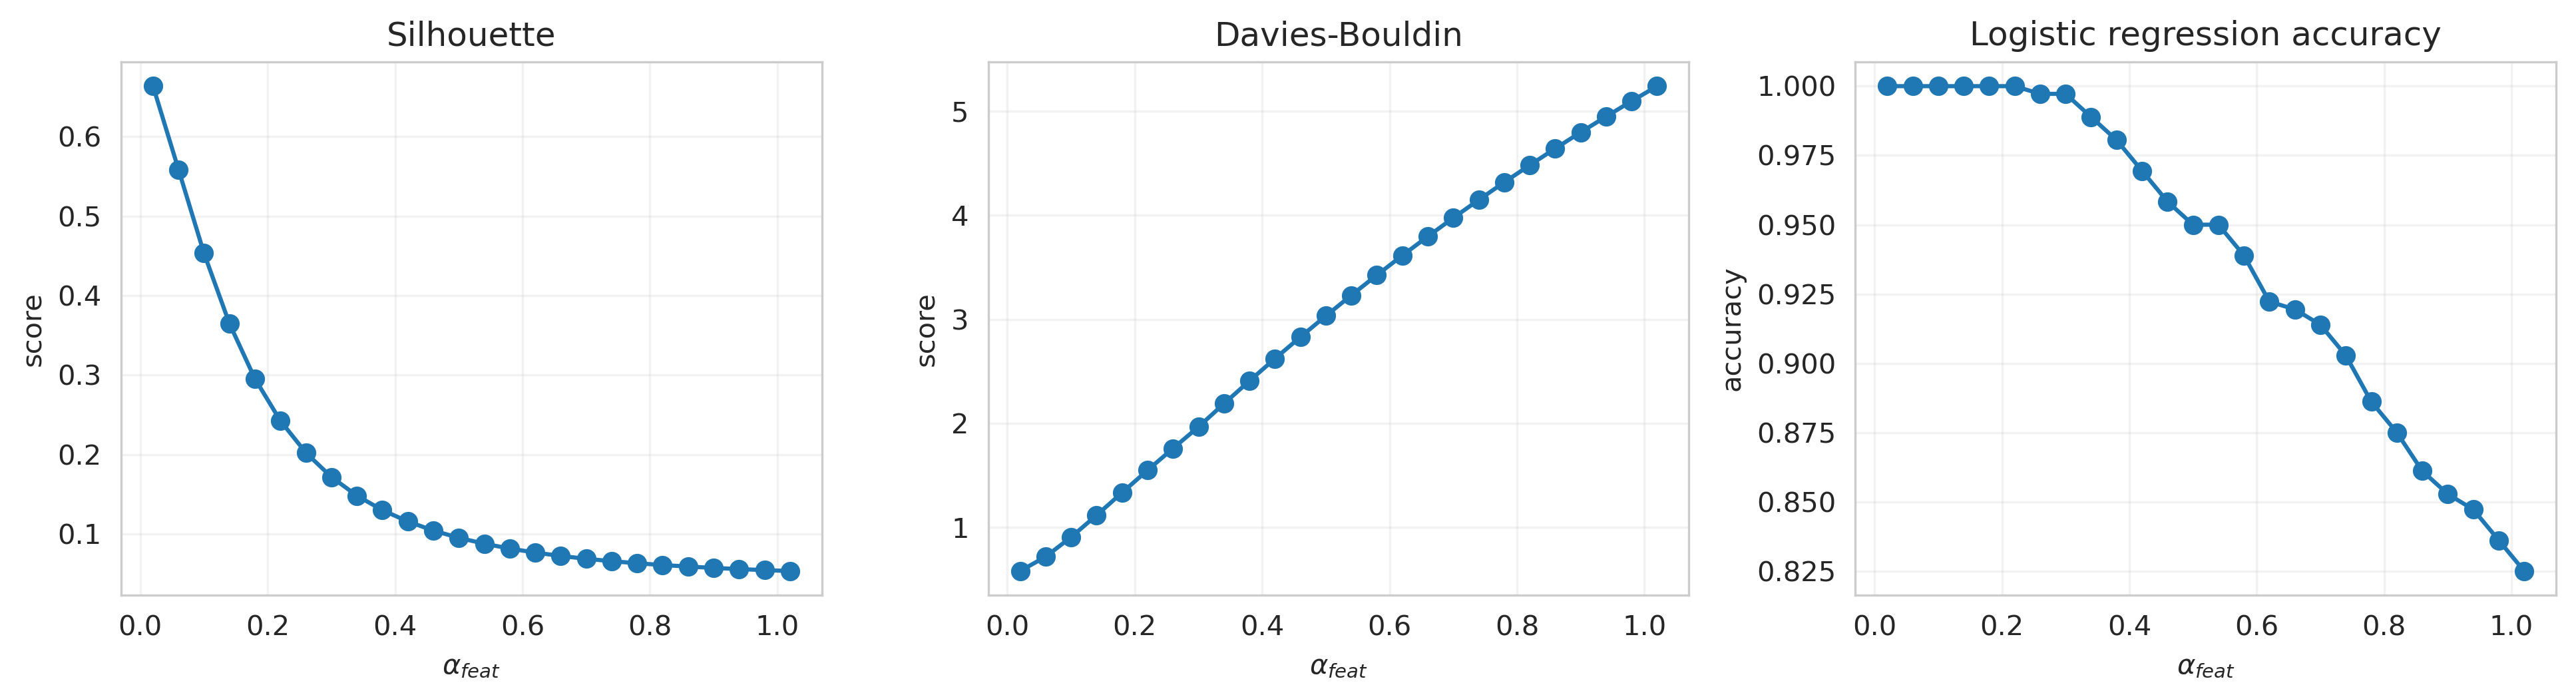

In [29]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


def intra_inter_distances(X, labels):
    intra_values = []
    inter_values = []

    classes = np.unique(labels)

    for c in classes:
        Xc = X[labels == c]
        D = pairwise_distances(Xc)
        tri = np.triu_indices_from(D, k=1)
        intra_values.append(D[tri].mean())

    for i, c1 in enumerate(classes):
        for c2 in classes[i + 1:]:
            X1 = X[labels == c1]
            X2 = X[labels == c2]
            D = pairwise_distances(X1, X2)
            inter_values.append(D.mean())

    return np.mean(intra_values), np.mean(inter_values)


def classifier_accuracy(X, labels, seed=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        labels,
        test_size=0.3,
        random_state=seed,
        stratify=labels,
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, random_state=seed),
    )

    clf.fit(X_train, y_train)
    return clf.score(X_test, y_test)


alpha_feat_values = [0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
alpha_feat_values = [round(0.02 * x,2) for x in range(1,52,2)]
rows = []

for alpha_feat in alpha_feat_values:
    graph = generate_scatt(
        alpha_feat=alpha_feat,
        alpha_topo=0.0,  # fixa sem suavizacao topologica para isolar o efeito do ruido nas features
        seed=42,
    )

    X, labels = graph_to_numpy(graph)

    intra_dist, inter_dist = intra_inter_distances(X, labels)

    rows.append({
        "alpha_feat": alpha_feat,
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "mean_intra_distance": intra_dist,
        "mean_inter_distance": inter_dist,
        "inter_over_intra": inter_dist / intra_dist,
        "logreg_accuracy": classifier_accuracy(X, labels),
    })

df_alpha_feat = pd.DataFrame(rows)
display(df_alpha_feat)


fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), dpi=300)

axes[0].plot(df_alpha_feat["alpha_feat"], df_alpha_feat["silhouette"], marker="o")
axes[0].set_title("Silhouette")
axes[0].set_xlabel(r"$\alpha_{feat}$")
axes[0].set_ylabel("score")

axes[1].plot(df_alpha_feat["alpha_feat"], df_alpha_feat["davies_bouldin"], marker="o")
axes[1].set_title("Davies-Bouldin")
axes[1].set_xlabel(r"$\alpha_{feat}$")
axes[1].set_ylabel("score")

axes[2].plot(df_alpha_feat["alpha_feat"], df_alpha_feat["logreg_accuracy"], marker="o")
axes[2].set_title("Logistic regression accuracy")
axes[2].set_xlabel(r"$\alpha_{feat}$")
axes[2].set_ylabel("accuracy")

for ax in axes:
    ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()


In [7]:
from itertools import product

from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy as np

# alpha_feat_values = np.round(np.arange(0.0, 1.0 + 0.02, 0.02), 2)
alpha_feat_values = np.round(np.arange(0.0, 1.0 + 0.02, 0.1), 2)

# alpha_topo_values = np.round(np.arange(0.0, 1.0 + 0.02, 0.02), 2)
alpha_topo_values = np.round(np.arange(0.0, 1.0 + 0.02, 0.1), 2)


rows = []

for alpha_feat, alpha_topo in product(alpha_feat_values, alpha_topo_values):
    print(alpha_feat, alpha_topo)
    graph = generate_scatt(
        alpha_feat=alpha_feat,
        alpha_topo=alpha_topo,
        seed=42,
    )

    X, labels = graph_to_numpy(graph)

    rows.append({
        "alpha_feat": alpha_feat,
        "alpha_topo": alpha_topo,
        "silhouette": silhouette_score(X, labels),
    })

df_alpha_grid = pd.DataFrame(rows)
display(df_alpha_grid)

0.0 0.0
0.0 0.1
0.0 0.2
0.0 0.3
0.0 0.4
0.0 0.5
0.0 0.6
0.0 0.7
0.0 0.8
0.0 0.9
0.0 1.0
0.1 0.0
0.1 0.1
0.1 0.2
0.1 0.3
0.1 0.4
0.1 0.5
0.1 0.6
0.1 0.7
0.1 0.8
0.1 0.9
0.1 1.0
0.2 0.0
0.2 0.1
0.2 0.2
0.2 0.3
0.2 0.4
0.2 0.5
0.2 0.6
0.2 0.7
0.2 0.8
0.2 0.9
0.2 1.0
0.3 0.0
0.3 0.1
0.3 0.2
0.3 0.3
0.3 0.4
0.3 0.5
0.3 0.6
0.3 0.7
0.3 0.8
0.3 0.9
0.3 1.0
0.4 0.0
0.4 0.1
0.4 0.2
0.4 0.3
0.4 0.4
0.4 0.5
0.4 0.6
0.4 0.7
0.4 0.8
0.4 0.9
0.4 1.0
0.5 0.0
0.5 0.1
0.5 0.2
0.5 0.3
0.5 0.4
0.5 0.5
0.5 0.6
0.5 0.7
0.5 0.8
0.5 0.9
0.5 1.0
0.6 0.0
0.6 0.1
0.6 0.2
0.6 0.3
0.6 0.4
0.6 0.5
0.6 0.6
0.6 0.7
0.6 0.8
0.6 0.9
0.6 1.0
0.7 0.0
0.7 0.1
0.7 0.2
0.7 0.3
0.7 0.4
0.7 0.5
0.7 0.6
0.7 0.7
0.7 0.8
0.7 0.9
0.7 1.0
0.8 0.0
0.8 0.1
0.8 0.2
0.8 0.3
0.8 0.4
0.8 0.5
0.8 0.6
0.8 0.7
0.8 0.8
0.8 0.9
0.8 1.0
0.9 0.0
0.9 0.1
0.9 0.2
0.9 0.3
0.9 0.4
0.9 0.5
0.9 0.6
0.9 0.7
0.9 0.8
0.9 0.9
0.9 1.0
1.0 0.0
1.0 0.1
1.0 0.2
1.0 0.3
1.0 0.4
1.0 0.5
1.0 0.6
1.0 0.7
1.0 0.8
1.0 0.9
1.0 1.0


,alpha_feat,alpha_topo,silhouette
0,0.0,0.0,0.701596
1,0.0,0.1,0.720256
2,0.0,0.2,0.740458
3,0.0,0.3,0.762416
4,0.0,0.4,0.786392
...,...,...,...
116,1.0,0.6,0.024459
117,1.0,0.7,0.016431
118,1.0,0.8,0.010224
119,1.0,0.9,0.006007


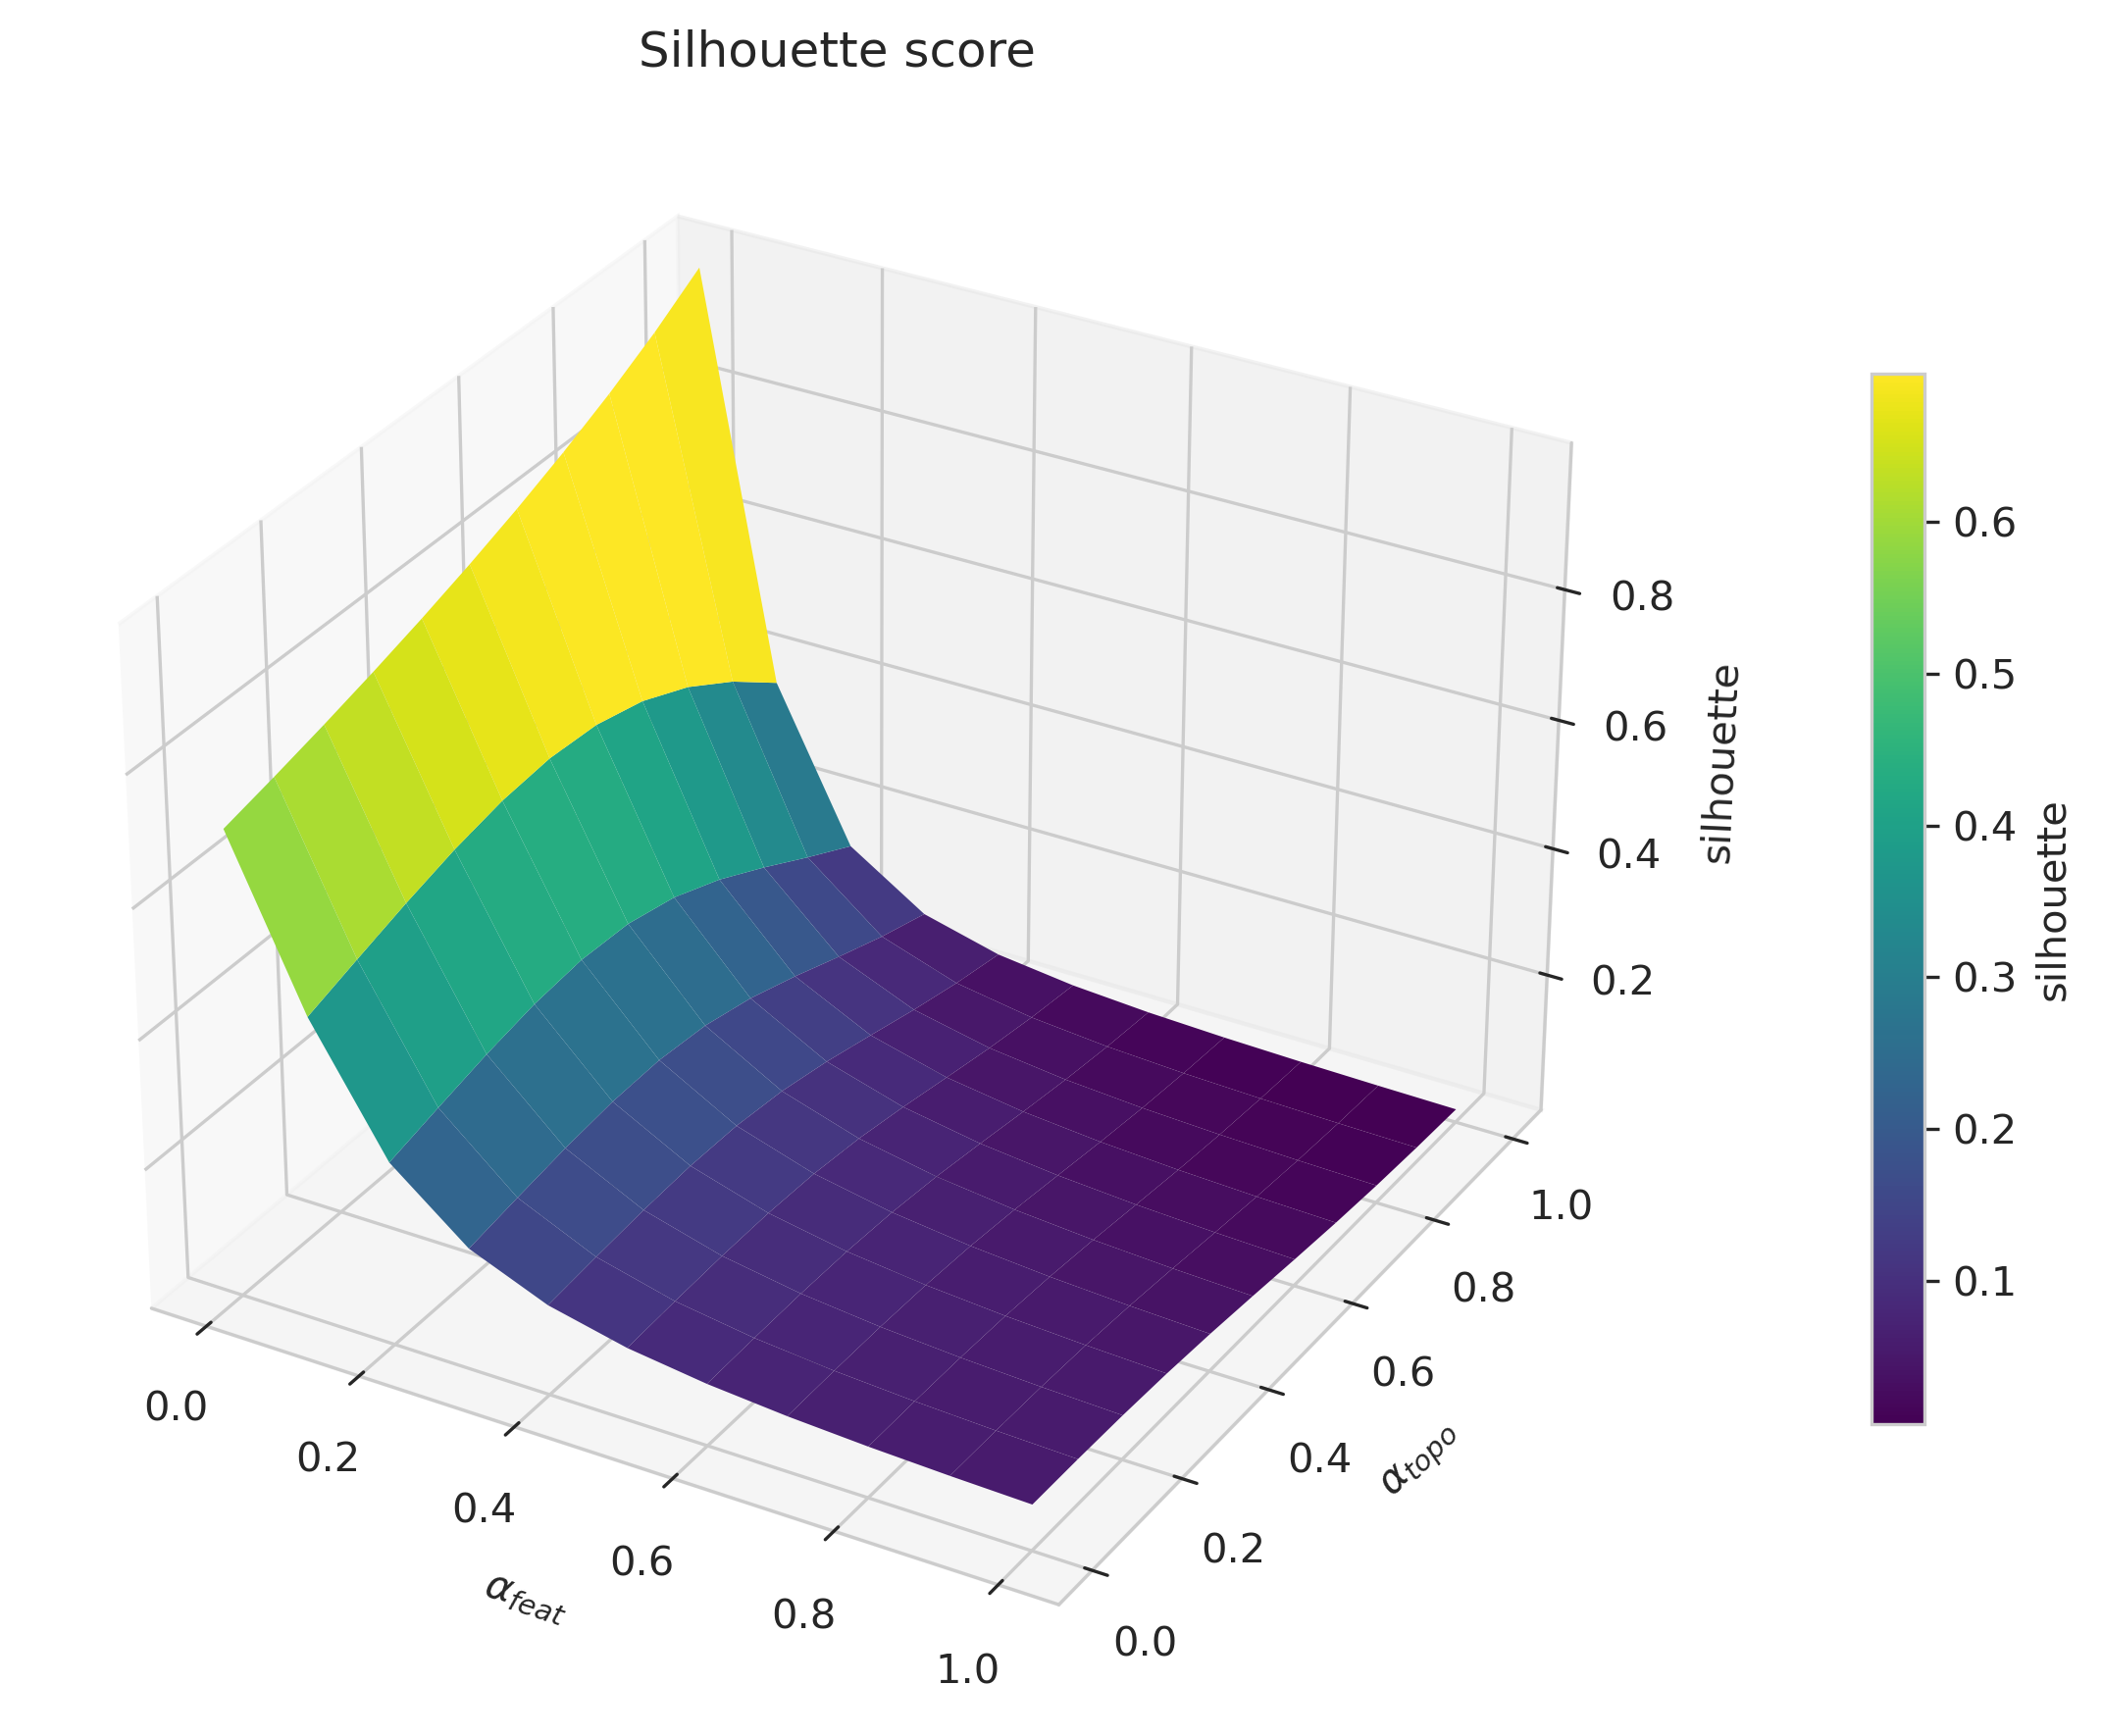

In [8]:
Z = df_alpha_grid.pivot(
    index="alpha_topo",
    columns="alpha_feat",
    values="silhouette",
)

X_grid, Y_grid = np.meshgrid(
    Z.columns.to_numpy(),
    Z.index.to_numpy(),
)

fig = plt.figure(figsize=(8, 6), dpi=300)
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    X_grid,
    Y_grid,
    Z.to_numpy(),
    cmap="viridis",
    edgecolor="none",
    antialiased=True,
)

ax.set_title("Silhouette score")
ax.set_xlabel(r"$\alpha_{feat}$")
ax.set_ylabel(r"$\alpha_{topo}$")
ax.set_zlabel("silhouette")

fig.colorbar(surface, ax=ax, shrink=0.65, pad=0.1, label="silhouette")

plt.tight_layout()
plt.show()

In [21]:
def set_pca_limits(ax, X_pca, pad_frac=0.18, min_span=4.0):
    x = X_pca[:, 0]
    y = X_pca[:, 1]

    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()

    x_span = max(x_max - x_min, min_span)
    y_span = max(y_max - y_min, min_span)

    x_center = 0.5 * (x_min + x_max)
    y_center = 0.5 * (y_min + y_max)

    span = max(x_span, y_span)
    span = span * (1 + pad_frac)

    ax.set_xlim(x_center - span / 2, x_center + span / 2)
    ax.set_ylim(y_center - span / 2, y_center + span / 2)
    ax.set_aspect("equal", adjustable="box")

/tmp/ipykernel_1221667/2571137658.py:86: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  fig.tight_layout()


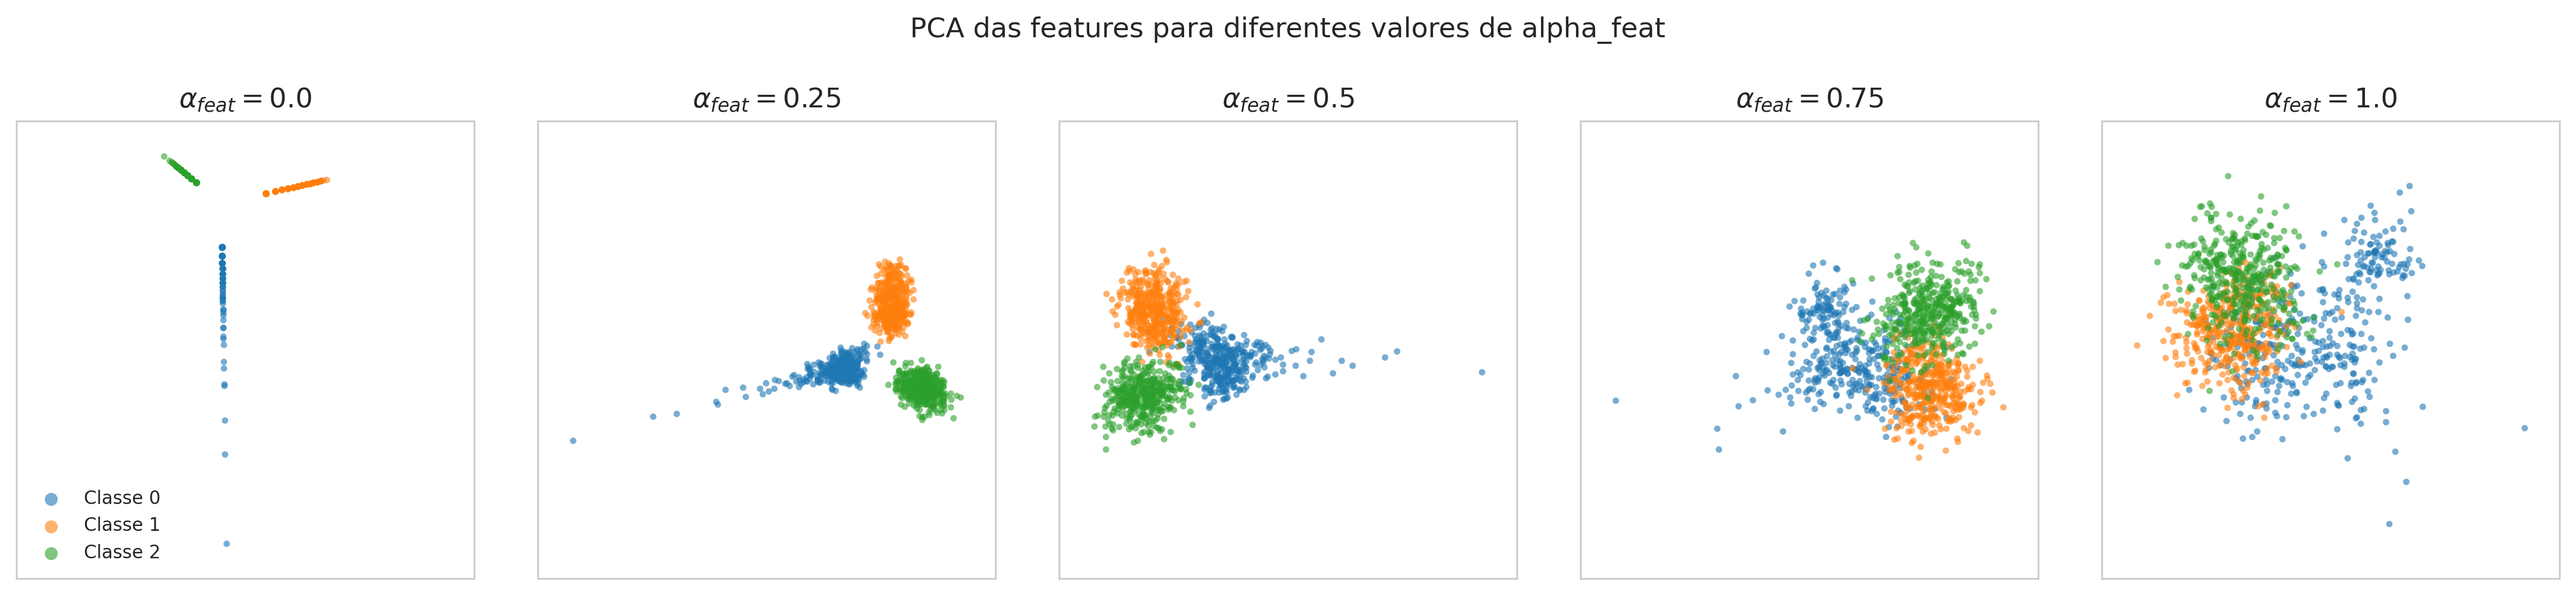

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


alpha_feat_values = [0.0, 0.25, 0.5, 0.75, 1.0]

# fig, axes = plt.subplots(1, len(alpha_feat_values), figsize=(16, 3.3), dpi=300, sharex=True, sharey=True)

fig, axes = plt.subplots(
    1,
    5,
    figsize=(16, 3.4),
    dpi=300,
    sharex=False,
    sharey=False,
    constrained_layout=True,
)

# fig, axes = plt.subplots(
#     2,
#     5,
#     figsize=(18, 7.2),
#     dpi=300,
#     sharex=False,
#     sharey=False,
# )

# fig.subplots_adjust(
#     wspace=0.12,
#     hspace=0.25,
#     bottom=0.12,
#     top=0.9,
# )

for ax, alpha_feat in zip(axes, alpha_feat_values):
    graph = generate_scatt(
        # alpha_feat=0.2,
        # alpha_topo=alpha_topo,
        alpha_feat=alpha_feat,
        alpha_topo=0.5,
        seed=42,
    )

    X, labels = graph_to_numpy(graph)

    X_scaled = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

    x_min, x_max = np.percentile(X_pca[:, 0], [1, 99])
    y_min, y_max = np.percentile(X_pca[:, 1], [1, 99])

    x_pad = 0.12 * (x_max - x_min)
    y_pad = 0.12 * (y_max - y_min)

    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.set_aspect("equal", adjustable="box")

    for c in np.unique(labels):
        mask = labels == c
        # ax.scatter(
        #     X_pca[mask, 0],
        #     X_pca[mask, 1],
        #     s=5,
        #     alpha=0.65,
        #     label=f"Classe {c}",
        # )


        ax.scatter(
    X_pca[mask, 0],
    X_pca[mask, 1],
    s=8,
    alpha=0.6,
    linewidths=0,
    label=f"Classe {c}",
)
    set_pca_limits(ax, X_pca)

    ax.set_title(rf"$\alpha_{{feat}}={alpha_feat}$")
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].legend(frameon=False, markerscale=2, fontsize=8)
fig.suptitle("PCA das features para diferentes valores de alpha_feat", y=1.05)
fig.tight_layout()
plt.show()


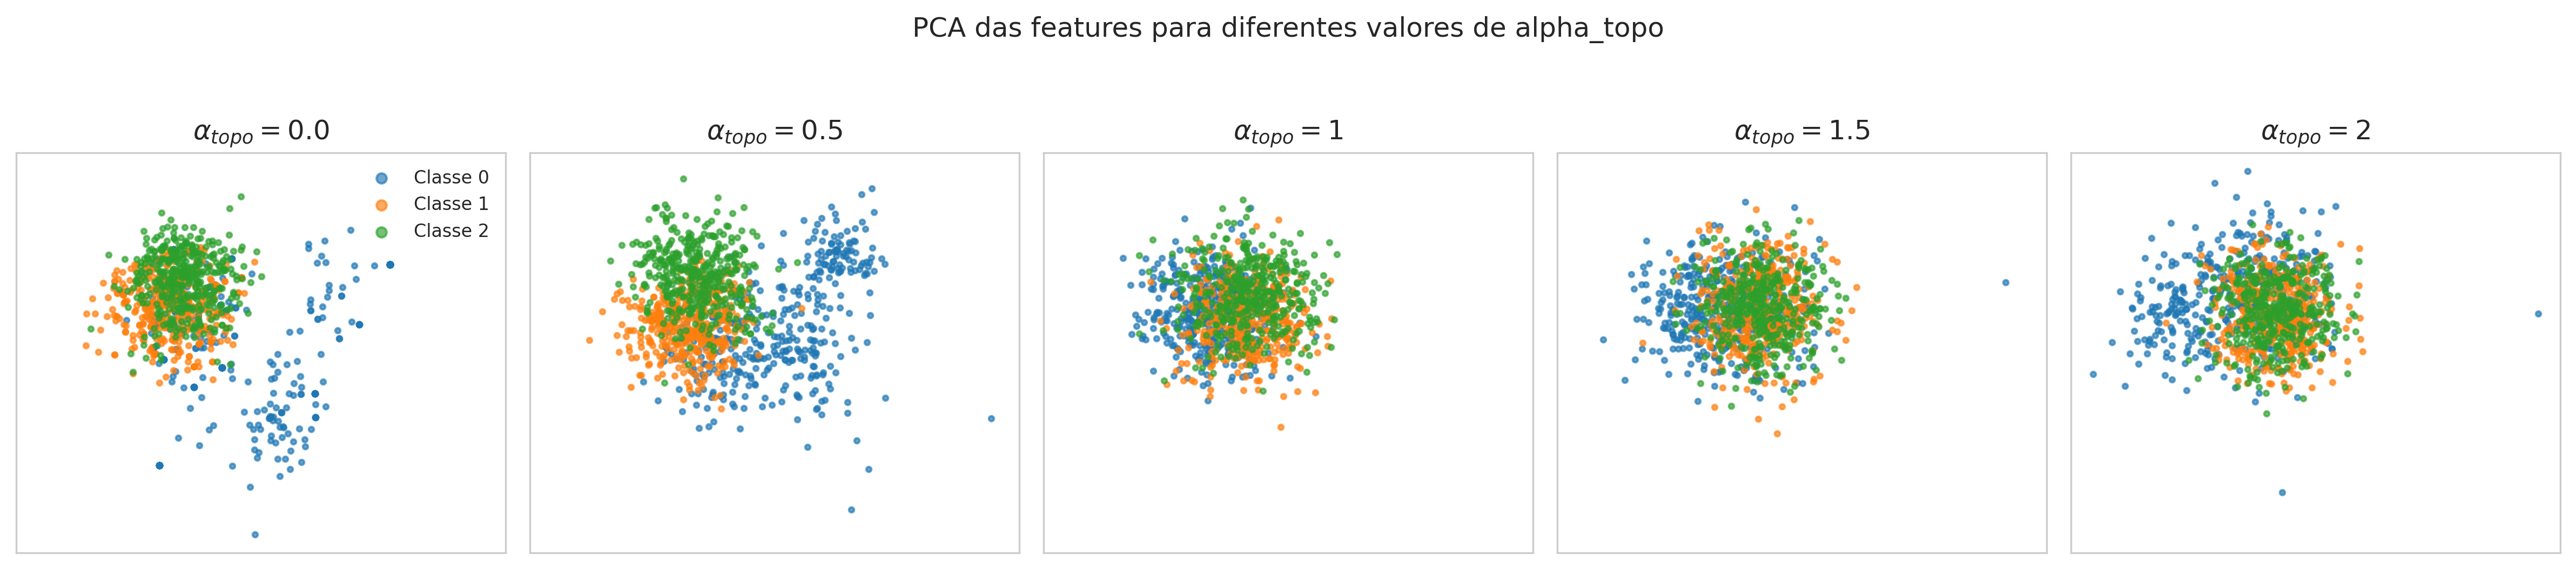

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


alpha_topo_values = [0.0, 0.5, 1, 1.5, 2]

fig, axes = plt.subplots(1, len(alpha_topo_values), figsize=(16, 3.3), dpi=300, sharex=True, sharey=True)

for ax, alpha_topo in zip(axes, alpha_topo_values):
    graph = generate_scatt(
        # alpha_feat=0.2,
        # alpha_topo=alpha_topo,
        alpha_feat=1,
        alpha_topo=alpha_topo,
        seed=42,
    )

    X, labels = graph_to_numpy(graph)

    X_scaled = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

    for c in np.unique(labels):
        mask = labels == c
        ax.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            s=5,
            alpha=0.65,
            label=f"Classe {c}",
        )

    ax.set_title(rf"$\alpha_{{topo}}={alpha_topo}$")
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].legend(frameon=False, markerscale=2, fontsize=8)
fig.suptitle("PCA das features para diferentes valores de alpha_topo", y=1.05)
fig.tight_layout()
plt.show()


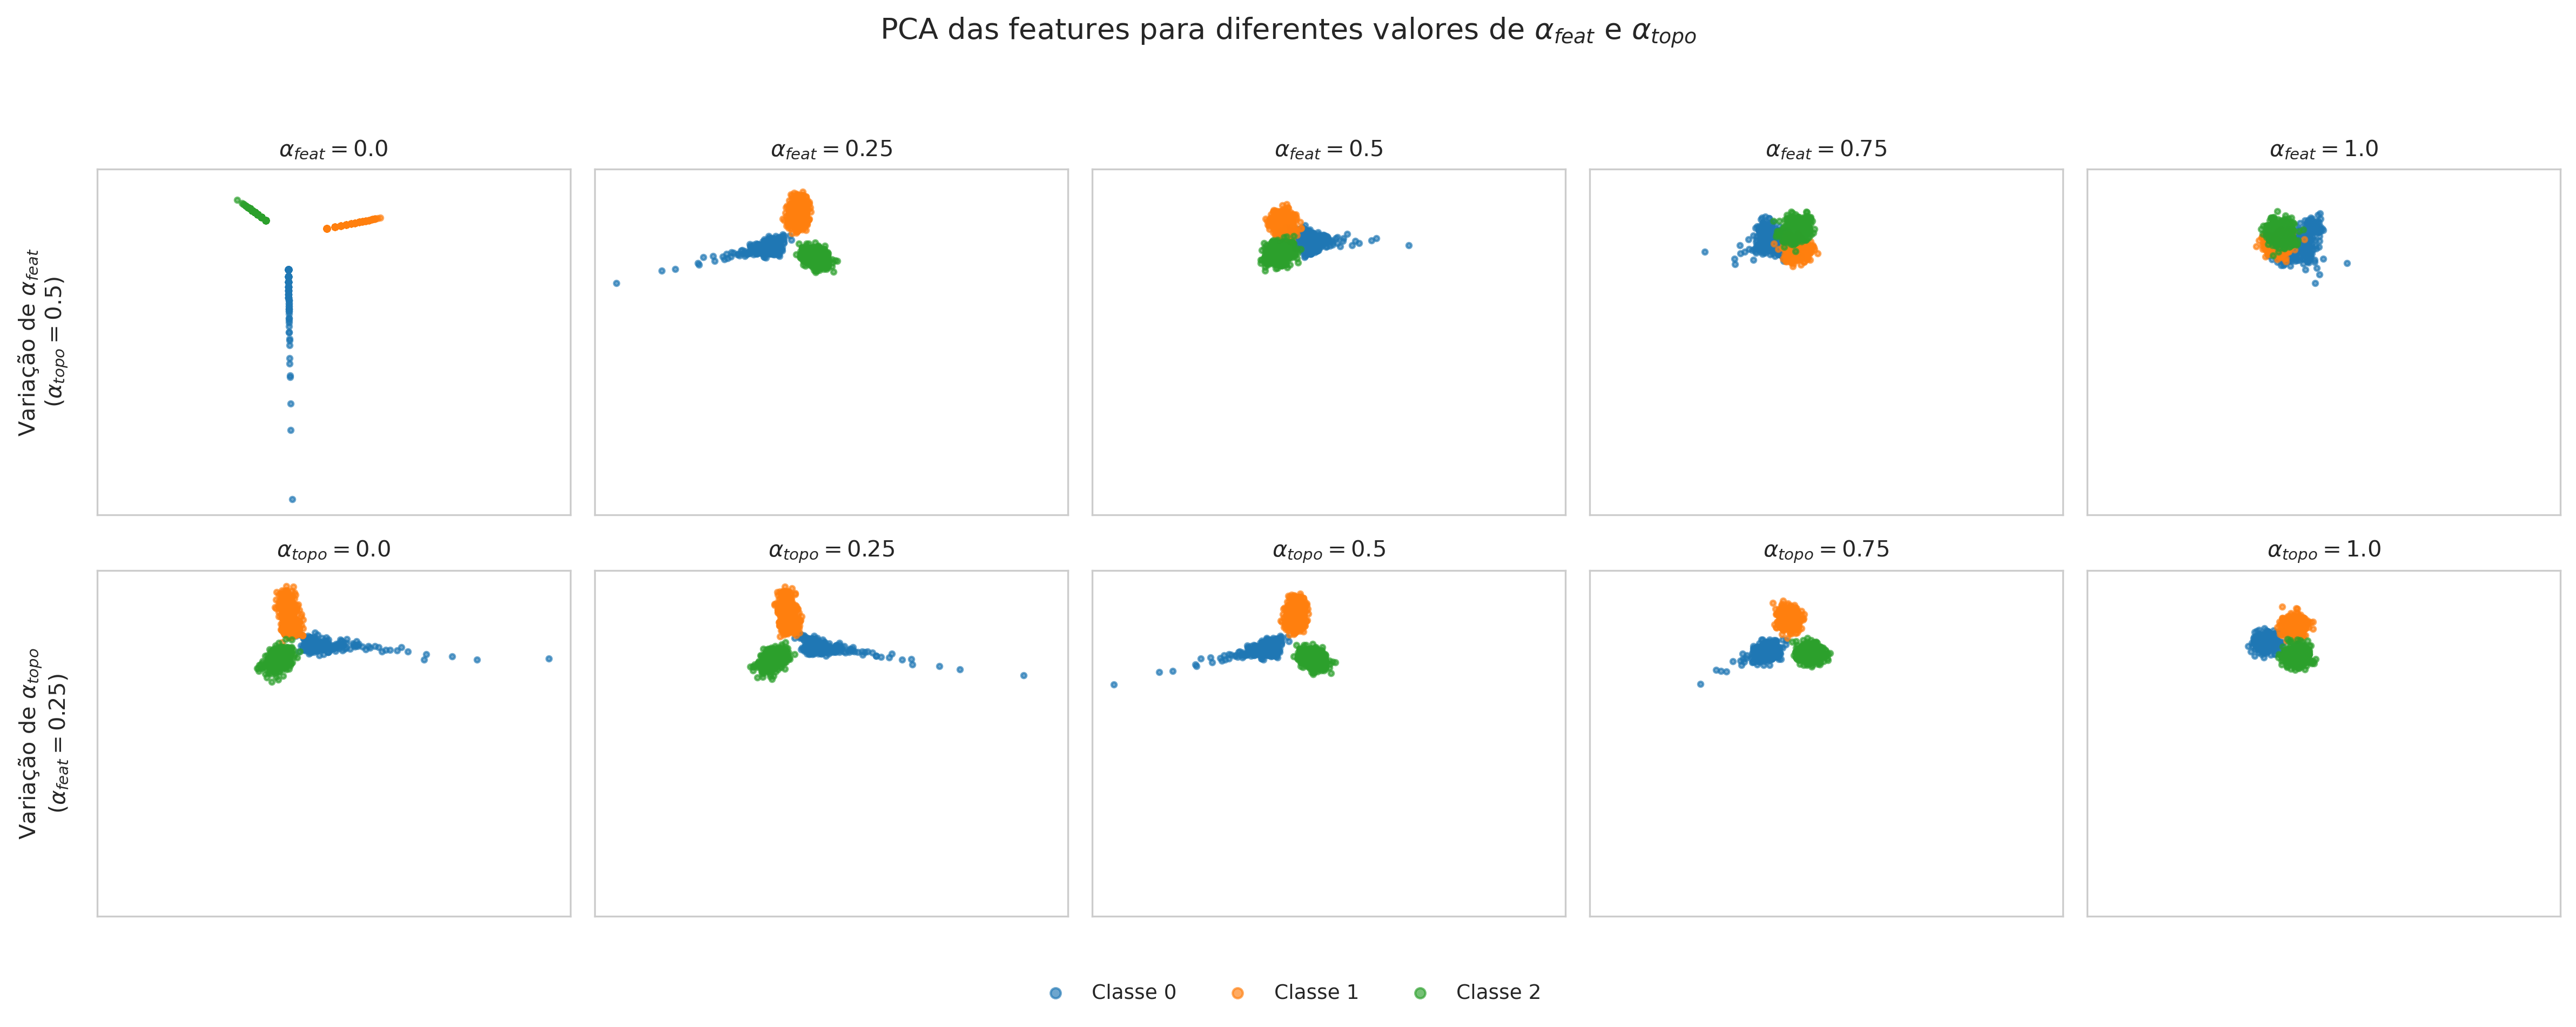

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


alpha_feat_values = [0.0, 0.25, 0.5, 0.75, 1.0]
alpha_topo_values = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(
    2,
    5,
    figsize=(16, 6.2),
    dpi=300,
    sharex=True,
    sharey=True
)

# ============================================================
# Linha 1: variação de alpha_feat, mantendo alpha_topo = 0.5
# ============================================================

for ax, alpha_feat in zip(axes[0], alpha_feat_values):
    graph = generate_scatt(
        alpha_feat=alpha_feat,
        alpha_topo=0.5,
        seed=42,
    )

    X, labels = graph_to_numpy(graph)

    X_scaled = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

    for c in np.unique(labels):
        mask = labels == c
        ax.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            s=5,
            alpha=0.65,
            label=f"Classe {c}",
        )

    ax.set_title(rf"$\alpha_{{feat}}={alpha_feat}$", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])


# ============================================================
# Linha 2: variação de alpha_topo, mantendo alpha_feat = 0.25
# ============================================================

for ax, alpha_topo in zip(axes[1], alpha_topo_values):
    graph = generate_scatt(
        alpha_feat=0.25,
        alpha_topo=alpha_topo,
        seed=42,
    )

    X, labels = graph_to_numpy(graph)

    X_scaled = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

    for c in np.unique(labels):
        mask = labels == c
        ax.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            s=5,
            alpha=0.65,
            label=f"Classe {c}",
        )

    ax.set_title(rf"$\alpha_{{topo}}={alpha_topo}$", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])


# ============================================================
# Identificação das linhas
# ============================================================

axes[0, 0].set_ylabel(
    r"Variação de $\alpha_{feat}$"
    "\n"
    r"$(\alpha_{topo}=0.5)$",
    fontsize=10,
    labelpad=12
)

axes[1, 0].set_ylabel(
    r"Variação de $\alpha_{topo}$"
    "\n"
    r"$(\alpha_{feat}=0.25)$",
    fontsize=10,
    labelpad=12
)


# ============================================================
# Legenda única para toda a figura
# ============================================================

handles, legend_labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=len(np.unique(labels)),
    frameon=False,
    markerscale=2,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.01)
)


# ============================================================
# Título geral e ajustes finais
# ============================================================

fig.suptitle(
    r"PCA das features para diferentes valores de $\alpha_{feat}$ e $\alpha_{topo}$",
    fontsize=13,
    y=0.99
)

fig.tight_layout(rect=[0, 0.07, 1, 0.95])

# Opcional: salvar a figura
# fig.savefig("pca_alpha_feat_alpha_topo.png", dpi=300, bbox_inches="tight")

plt.show()

,alpha_topo,connected_cosine_mean,connected_cosine_std,non_connected_cosine_mean,non_connected_cosine_std,gap_connected_minus_non_connected
0,0.00,0.486089,0.226011,0.217724,0.195045,0.268365
1,0.25,0.609503,0.176432,0.234519,0.201405,0.374984
2,0.50,0.651761,0.147434,0.207614,0.196450,0.444146
3,0.75,0.472864,0.150726,0.126518,0.172577,0.346345
4,1.00,0.125310,0.141945,0.050564,0.147586,0.074746


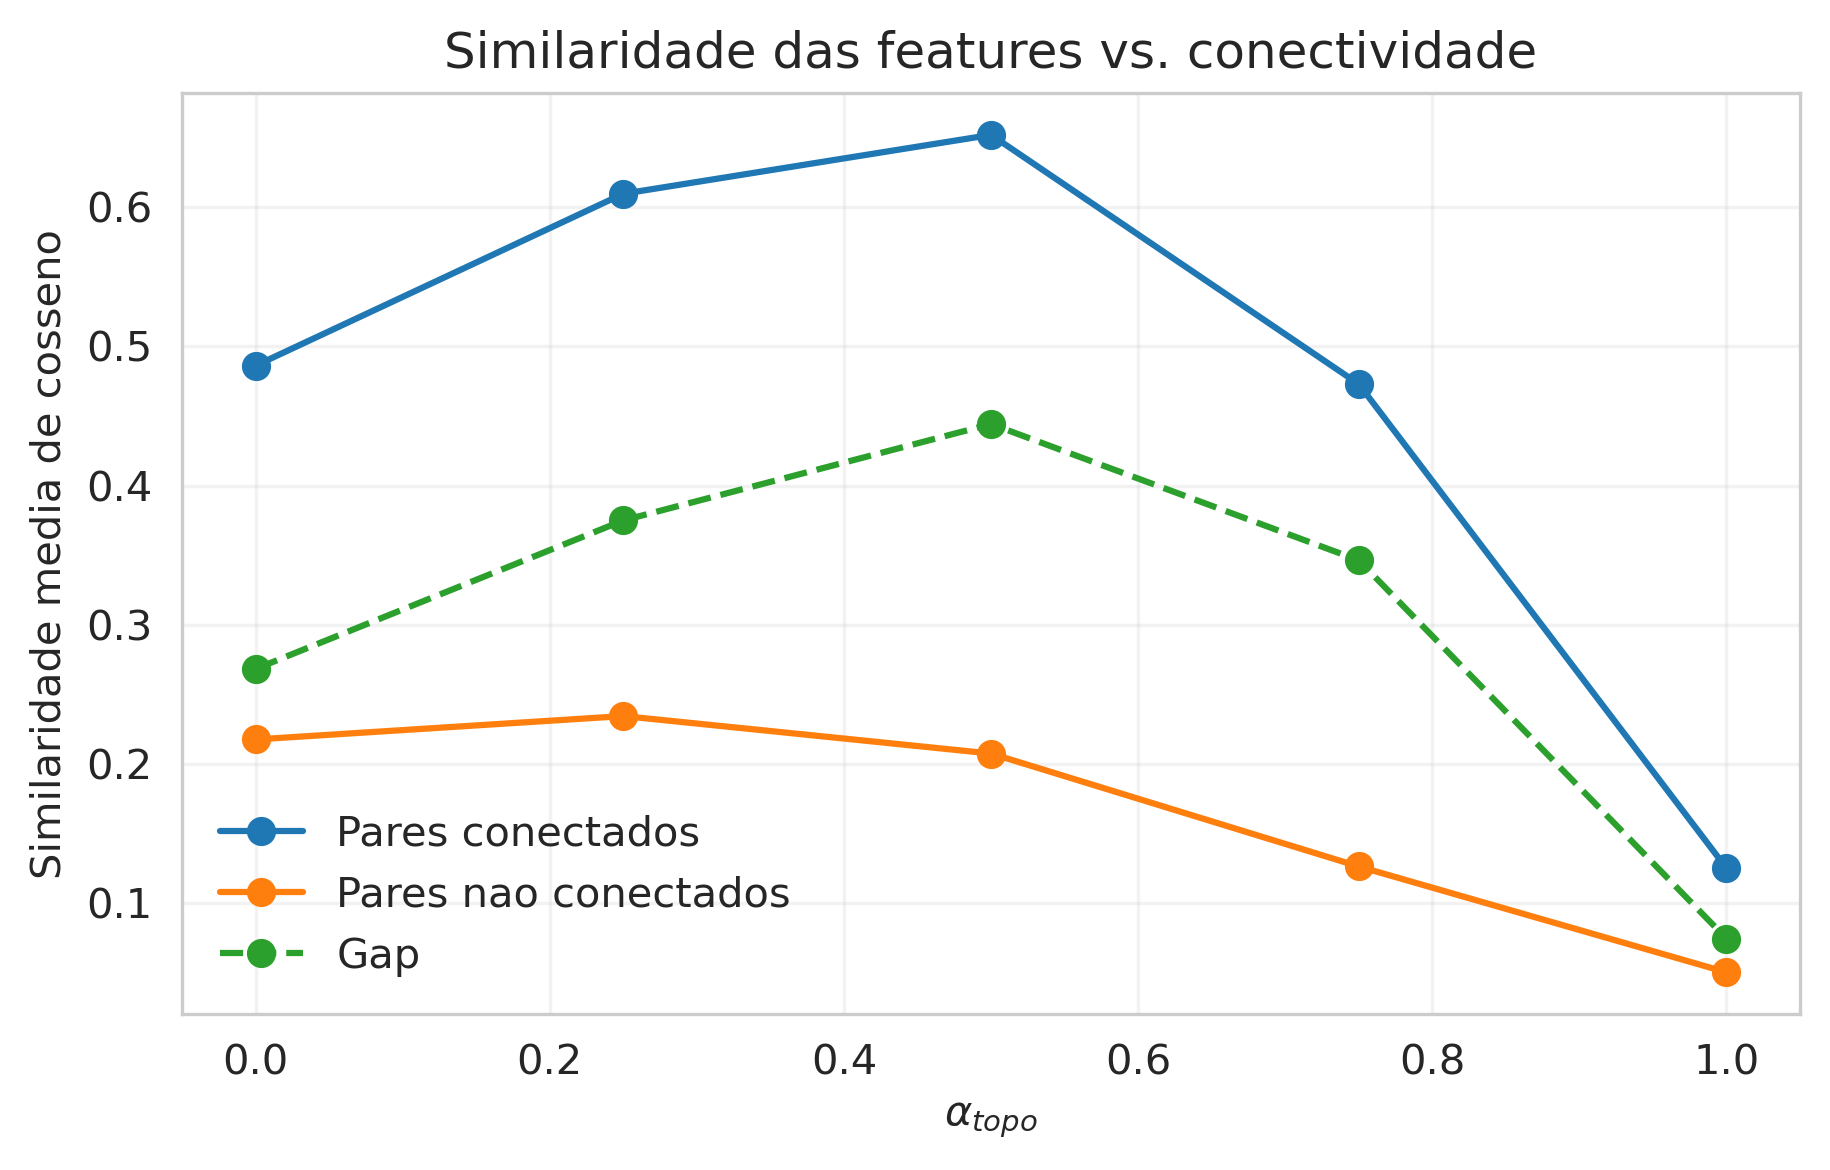

In [17]:
from sklearn.preprocessing import normalize


def edge_set_from_graph(graph):
    return {tuple(sorted((int(u), int(v)))) for u, v in graph.graph.iterEdges()}


def sample_non_edges(num_nodes, existing_edges, n_samples, seed=42):
    rng = np.random.default_rng(seed)
    non_edges = set()

    while len(non_edges) < n_samples:
        u = int(rng.integers(0, num_nodes))
        v = int(rng.integers(0, num_nodes))

        if u == v:
            continue

        edge = tuple(sorted((u, v)))
        if edge in existing_edges:
            continue

        non_edges.add(edge)

    return list(non_edges)


def mean_cosine_for_pairs(X_norm, pairs):
    values = [
        float(np.dot(X_norm[u], X_norm[v]))
        for u, v in pairs
    ]
    return np.mean(values), np.std(values)


alpha_topo_values = [0.0, 0.25, 0.5, 0.75, 1.0]
rows = []

for alpha_topo in alpha_topo_values:
    graph = generate_scatt(
        alpha_feat=0.3,
        alpha_topo=alpha_topo,
        seed=42,
    )

    X, labels = graph_to_numpy(graph)
    X_norm = normalize(X)

    edges = list(edge_set_from_graph(graph))
    non_edges = sample_non_edges(
        num_nodes=graph.num_nodes(),
        existing_edges=set(edges),
        n_samples=len(edges),
        seed=42,
    )

    edge_mean, edge_std = mean_cosine_for_pairs(X_norm, edges)
    non_edge_mean, non_edge_std = mean_cosine_for_pairs(X_norm, non_edges)

    rows.append({
        "alpha_topo": alpha_topo,
        "connected_cosine_mean": edge_mean,
        "connected_cosine_std": edge_std,
        "non_connected_cosine_mean": non_edge_mean,
        "non_connected_cosine_std": non_edge_std,
        "gap_connected_minus_non_connected": edge_mean - non_edge_mean,
    })

df_topo_similarity = pd.DataFrame(rows)
display(df_topo_similarity)


fig, ax = plt.subplots(figsize=(6.2, 4.0), dpi=300)

ax.plot(
    df_topo_similarity["alpha_topo"],
    df_topo_similarity["connected_cosine_mean"],
    marker="o",
    label="Pares conectados",
)

ax.plot(
    df_topo_similarity["alpha_topo"],
    df_topo_similarity["non_connected_cosine_mean"],
    marker="o",
    label="Pares nao conectados",
)

ax.plot(
    df_topo_similarity["alpha_topo"],
    df_topo_similarity["gap_connected_minus_non_connected"],
    marker="o",
    linestyle="--",
    label="Gap",
)

ax.set_xlabel(r"$\alpha_{topo}$")
ax.set_ylabel("Similaridade media de cosseno")
ax.set_title("Similaridade das features vs. conectividade")
ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()


KeyError: 'rho'

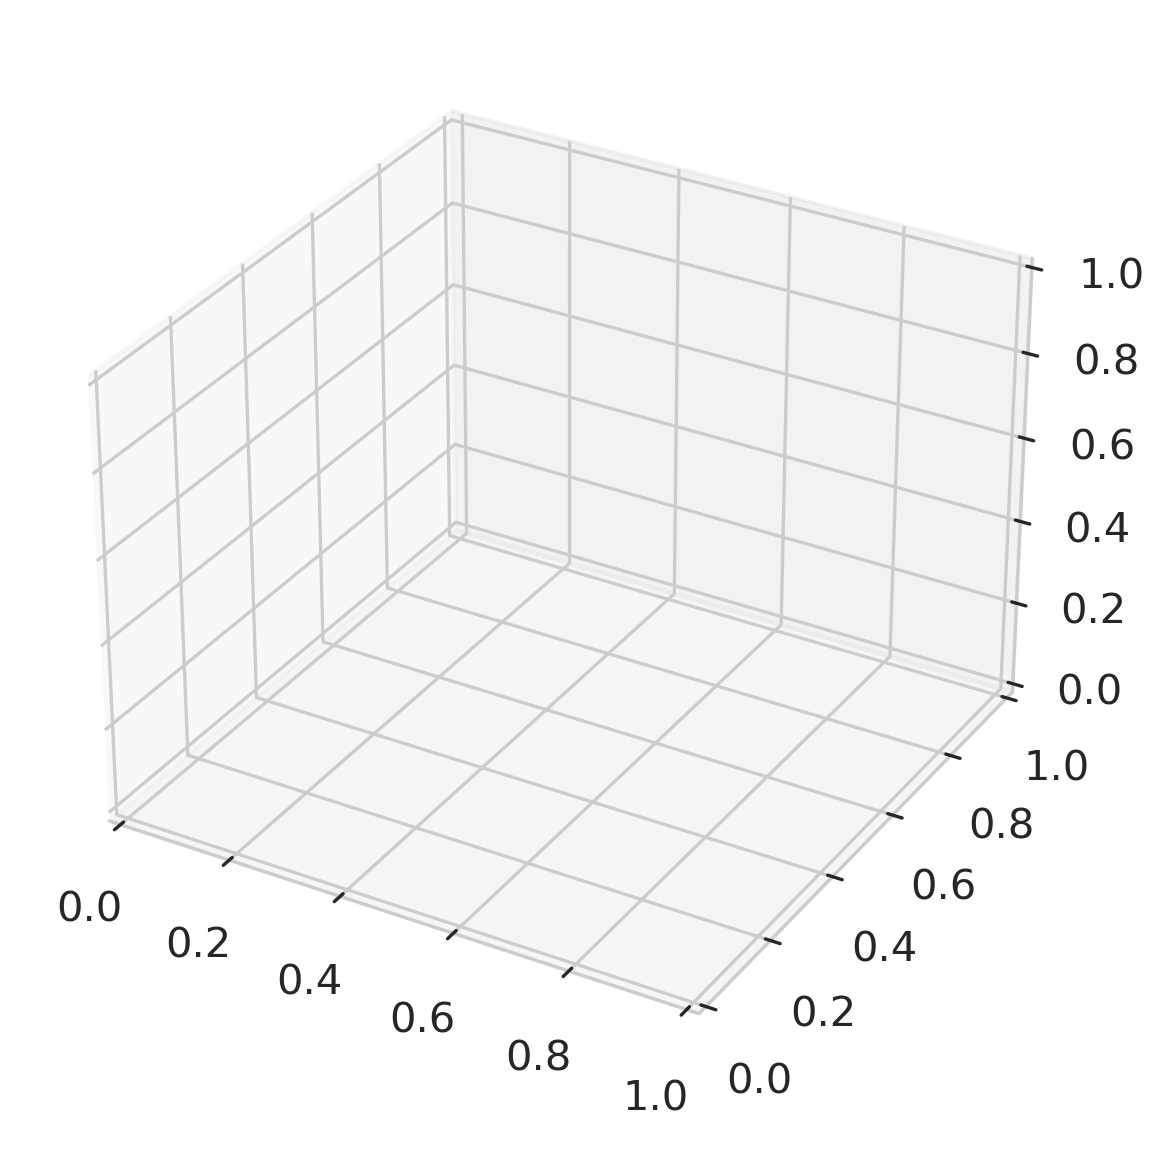

In [23]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


# import warnings
# import numpy as np
# import pandas as pd
# import torch
# import matplotlib.pyplot as plt

from models.SCatt import SCAttGenerator

# ============================================================
# Configuracao base do grafo
# ============================================================

y = [40, 40, 40]
k = len(y)
n = sum(y)
d = 60
rho_list = [2000]
df_silhouette_grid = pd.DataFrame()
# ============================================================
# Plot 3D: uma superficie por rho
# ============================================================

fig = plt.figure(figsize=(18, 10), dpi=300)

for idx, rho in enumerate(rho_list, start=1):
    ax = fig.add_subplot(2, 3, idx, projection="3d")

    df_rho = df_silhouette_grid[df_silhouette_grid["rho"] == rho]

    Z = df_rho.pivot(
        index="alpha_feat",
        columns="alpha_topo",
        values="silhouette",
    )

    X_grid, Y_grid = np.meshgrid(
        Z.columns.to_numpy(),
        Z.index.to_numpy(),
    )

    surface = ax.plot_surface(
        X_grid,
        Y_grid,
        Z.to_numpy(),
        cmap="viridis",
        edgecolor="none",
        antialiased=True,
        alpha=0.95,
    )

    ax.set_title(rf"$\rho={rho}$", fontsize=11)
    ax.set_xlabel(r"$\alpha_{topo}$", labelpad=7)
    ax.set_ylabel(r"$\alpha_{feat}$", labelpad=7)
    ax.set_zlabel("Silhouette", labelpad=7)

    ax.view_init(elev=28, azim=-135)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    fig.colorbar(
        surface,
        ax=ax,
        shrink=0.55,
        pad=0.08,
    )

# Remove o sexto painel vazio, ja que temos 5 valores de rho
if len(rho_list) < 6:
    empty_ax = fig.add_subplot(2, 3, 6)
    empty_ax.axis("off")

fig.suptitle(
    r"Silhouette score para o grid $\alpha_{topo} \times \alpha_{feat}$",
    fontsize=14,
    y=0.98,
)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
e = [250, 200, 100]
rho_list = [550, 700, 900, 1100, 1200]

S = [
    torch.tensor([1.0]),
    torch.tensor([0.4, 0.3, 0.3]),
    torch.tensor([0.9, 0.1]),
]

A_in = [
    torch.tensor([[1.0]]),
    torch.tensor([
        [0.6, 0.3, 0.1],
        [0.1, 0.7, 0.2],
        [0.0, 0.3, 0.7],
    ]),
    torch.tensor([
        [0.9, 0.1],
        [0.1, 0.9],
    ]),
]

A_out = torch.tensor([
    [0.0, 0.5, 0.5],
    [0.5, 0.0, 0.5],
    [0.5, 0.5, 0.0],
])

dst = ["power_law", "normal", "uniform"]


# ============================================================
# Grid search alpha_topo x alpha_feat
# ============================================================

alpha_values = np.round(np.arange(0.0, 1.0 + 0.05, 0.05), 2)

rows = []

for rho in rho_list:
    print(f"Processando rho={rho}...")

    for alpha_topo in alpha_values:
        for alpha_feat in alpha_values:
            graph = SCAttGenerator(seed = 10101).generate(
                y=y,
                k=k,
                n=n,
                e=e,
                rho=rho,
                S=S,
                A_in=A_in,
                A_out=A_out,
                dst=dst,
                d=d,
                alpha_topo=float(alpha_topo),
                alpha_feat=float(alpha_feat),
            )

            X, labels = graph_to_numpy(graph)

            score = silhouette_score(X, labels)

            rows.append({
                "rho": rho,
                "alpha_topo": float(alpha_topo),
                "alpha_feat": float(alpha_feat),
                "silhouette": score,
            })

df_silhouette_grid = pd.DataFrame(rows)
display(df_silhouette_grid)

In [27]:
df_silhouette_grid.to_csv("new_grid_rho_alpha.csv")

e = [250, 200, 100]
rho_list = [550, 700, 900, 1100, 1200]

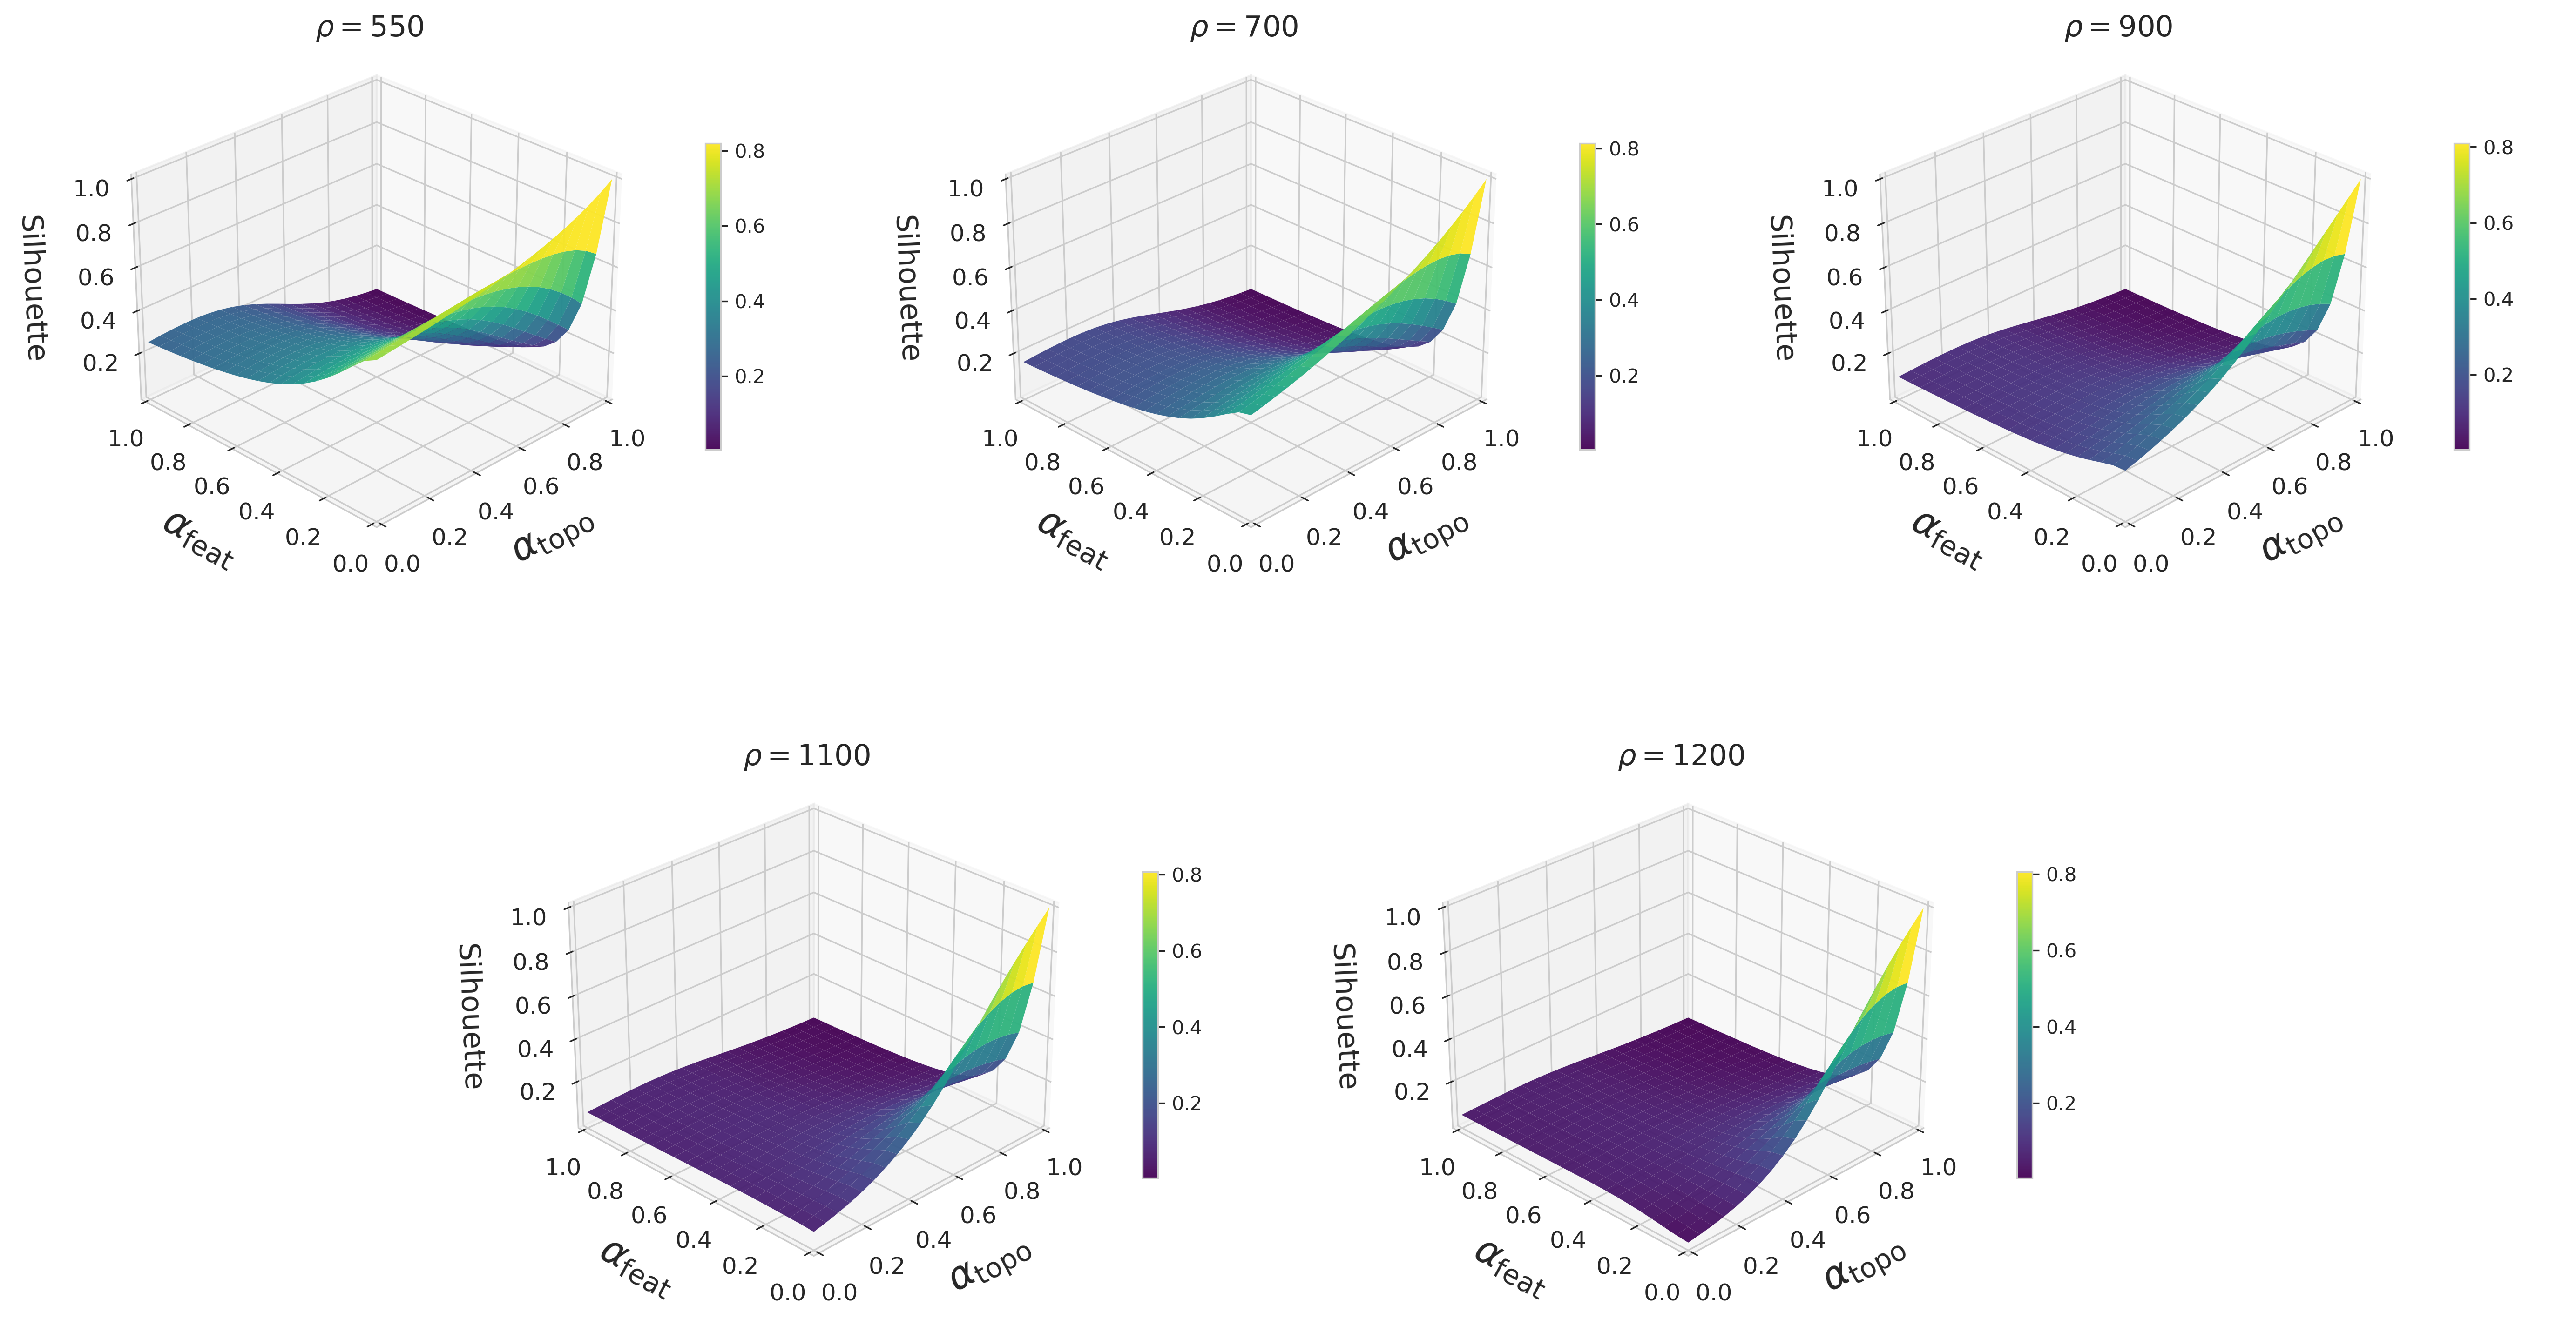

In [30]:
# ============================================================
# Plot 3D: uma superfície por rho
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

df_silhouette_grid = pd.read_csv("new_grid_rho_alpha.csv")

# Figura ligeiramente mais alta para aumentar a distância entre as linhas
fig = plt.figure(figsize=(19, 10), dpi=300)


gs = GridSpec(
    nrows=2,
    ncols=6,
    figure=fig,
    wspace=0.55,
    hspace=0.38,
)

# Posições dos cinco gráficos
positions = [
    gs[0, 0:2],  # rho 1: superior esquerdo
    gs[0, 2:4],  # rho 2: superior central
    gs[0, 4:6],  # rho 3: superior direito
    gs[1, 1:3],  # rho 4: inferior esquerdo centralizado
    gs[1, 3:5],  # rho 5: inferior direito centralizado
]


for position, rho in zip(positions, rho_list):
    ax = fig.add_subplot(position, projection="3d")
    df_rho = df_silhouette_grid[df_silhouette_grid["rho"] == rho]

    Z = df_rho.pivot(
        index="alpha_feat",
        columns="alpha_topo",
        values="silhouette",
    )

    X_grid, Y_grid = np.meshgrid(
        Z.columns.to_numpy(),
        Z.index.to_numpy(),
    )

    surface = ax.plot_surface(
        X_grid,
        Y_grid,
        Z.to_numpy(),
        cmap="viridis",
        edgecolor="none",
        antialiased=True,
        alpha=0.95,
    )

    # Título e rótulos com fontes maiores
    ax.set_title(
        rf"$\rho = {rho}$",
        fontsize=15,
        pad=-2,
    )

    ax.set_xlabel(
        r"$\alpha_{\mathrm{topo}}$",
        fontsize=20,
        labelpad=10,
    )

    ax.set_ylabel(
        r"$\alpha_{\mathrm{feat}}$",
        fontsize=20,
        labelpad=10,
    )

    ax.set_zlabel(
        "Silhouette",
        fontsize=15,
        labelpad=10,
    )

    # Tamanho da fonte dos valores nos eixos
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.tick_params(axis="z", which="major", labelsize=12)

    ax.view_init(elev=28, azim=-135)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    cbar = fig.colorbar(
        surface,
        ax=ax,
        shrink=0.58,
        pad=0.10,
    )

    cbar.ax.tick_params(labelsize=10)

# Remove o sexto painel vazio, pois temos apenas cinco valores de rho
if len(rho_list) < 6:
    empty_ax = fig.add_subplot(2, 3, 6)
    empty_ax.axis("off")

# Ajuste manual dos espaçamentos entre os painéis
# hspace controla a distância vertical entre as duas linhas
# wspace controla a distância horizontal entre as colunas
fig.subplots_adjust(
    left=0.04,
    right=0.97,
    bottom=0.06,
    top=0.96,
    wspace=0.20,
    hspace=0.3,
)

# Salva antes de exibir a figura
fig.savefig(
    "silhouette.svg",
    format="svg",
    bbox_inches="tight",
)

# Opcional: também salvar uma versão rasterizada em alta resolução
fig.savefig(
    "silhouette.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()